# Gas Usage Distribution

### Questions:
1. What causes gas distribution?
2. How does cold vs warm storage access could affect gas costs?
3. What/How much is the cost impact of storage caching?

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')
from matplotlib.patches import Rectangle

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

data_path = Path('./data/performance-test-500voters-2026-02-03T12-06-19-226Z.csv')
df = pd.read_csv(data_path)
df.head()

,Voter Index,Voter Address,Candidate ID,Candidate Name,Gas Used,Effective Gas Price (wei),Effective Gas Price (gwei),Transaction Fee (wei) = gasUsed * effectiveGasPrice,Transaction Fee (gwei),Transaction Fee (ETH),Block Number,Timestamp
0,0,0x4C4ace7511e84987cc4050389642F6Ec3cd62f4F,12,Michael Jordan,77411,294856556,0.294857,2.280000e+13,22825.14086,0.000023,12,2026-02-03T12:06:17.963Z
1,1,0xd86508D25f63AE98c65464Bf0CeA3CCb9c41186E,4,Edward Norton,77411,273858066,0.273858,2.120000e+13,21199.62675,0.000021,13,2026-02-03T12:06:17.963Z
2,2,0xED16598f57987eED602FDeea211C1cf85F45379b,4,Edward Norton,60311,206824047,0.206824,1.250000e+13,12473.76510,0.000013,16,2026-02-03T12:06:17.963Z
3,3,0xFeF11b93Cdd879c89D0D6BEe2B23aFfCce1647f6,18,Steve Rogers,77411,189771922,0.189772,1.470000e+13,14690.43425,0.000015,17,2026-02-03T12:06:17.963Z
4,5,0x52Fe081b17D6B2C4e983E642c3177d928B7DD028,7,Helen Troy,77411,226275544,0.226276,1.750000e+13,17516.21614,0.000017,15,2026-02-03T12:06:17.963Z


In [2]:
gas_stats = df['Gas Used'].describe()
gas_stats

count      500.000000
mean     60993.128000
std       3354.153624
min      60275.000000
25%      60311.000000
50%      60311.000000
75%      60311.000000
max      77411.000000
Name: Gas Used, dtype: float64

In [3]:
unique_gas = df['Gas Used'].unique()
unique_gas

array([77411, 60311, 77399, 60299, 60275, 60287])

In [4]:
gas_sorted = sorted(df['Gas Used'].unique())
gas_sorted

[np.int64(60275),
 np.int64(60287),
 np.int64(60299),
 np.int64(60311),
 np.int64(77399),
 np.int64(77411)]

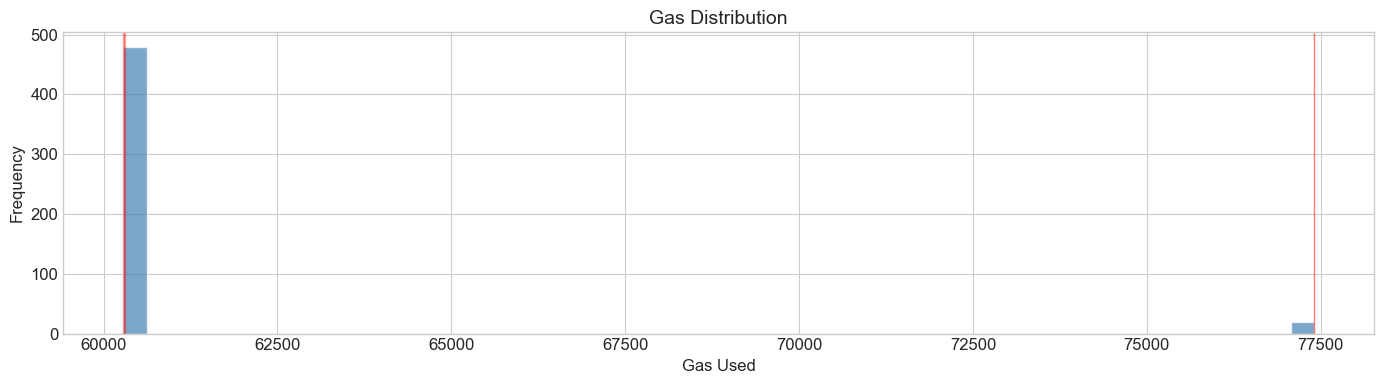

In [5]:
all_gas_values = sorted(df["Gas Used"].dropna().unique())

plt.figure(figsize=(14, 4))
df["Gas Used"].dropna().hist(bins=50, color="steelblue", edgecolor="white", alpha=0.7)

for gv in all_gas_values:
    plt.axvline(gv, color="red", alpha=0.3, linewidth=1)

plt.xlabel("Gas Used")
plt.ylabel("Frequency")
plt.title("Gas Distribution")
plt.tight_layout()
plt.show()

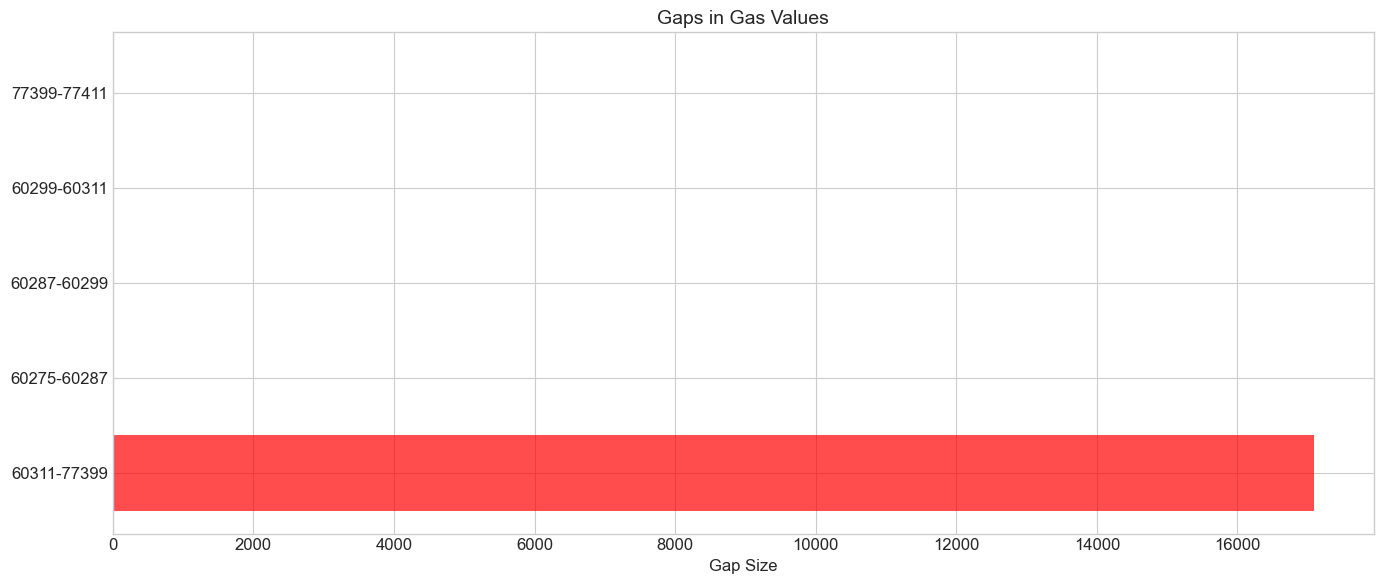

In [6]:
gas_diffs = []
for i in range(len(all_gas_values) - 1):
    diff = all_gas_values[i+1] - all_gas_values[i]
    gas_diffs.append((all_gas_values[i], all_gas_values[i+1], diff))

gas_diffs.sort(key=lambda x: x[2], reverse=True)

gap_positions = [f"{gd[0]}-{gd[1]}" for gd in gas_diffs[:15]]
gap_sizes = [gd[2] for gd in gas_diffs[:15]]
colors = ["red" if g > 1000 else "green" for g in gap_sizes]

plt.figure(figsize=(14, 6))
plt.barh(range(len(gap_sizes)), gap_sizes, color=colors, alpha=0.7)
plt.yticks(range(len(gap_sizes)), gap_positions)
plt.xlabel("Gap Size")
plt.title("Gaps in Gas Values")
plt.legend()
plt.tight_layout()
plt.show()

In [7]:
largest_gap = gas_diffs[0] 
largest_gap

(np.int64(60311), np.int64(77399), np.int64(17088))

In [8]:
max_warm = largest_gap[0]
max_warm

np.int64(60311)

In [9]:
min_cold = largest_gap[1]
min_cold

np.int64(77399)

In [10]:
threshold = (max_warm + min_cold) // 2
threshold

np.int64(68855)

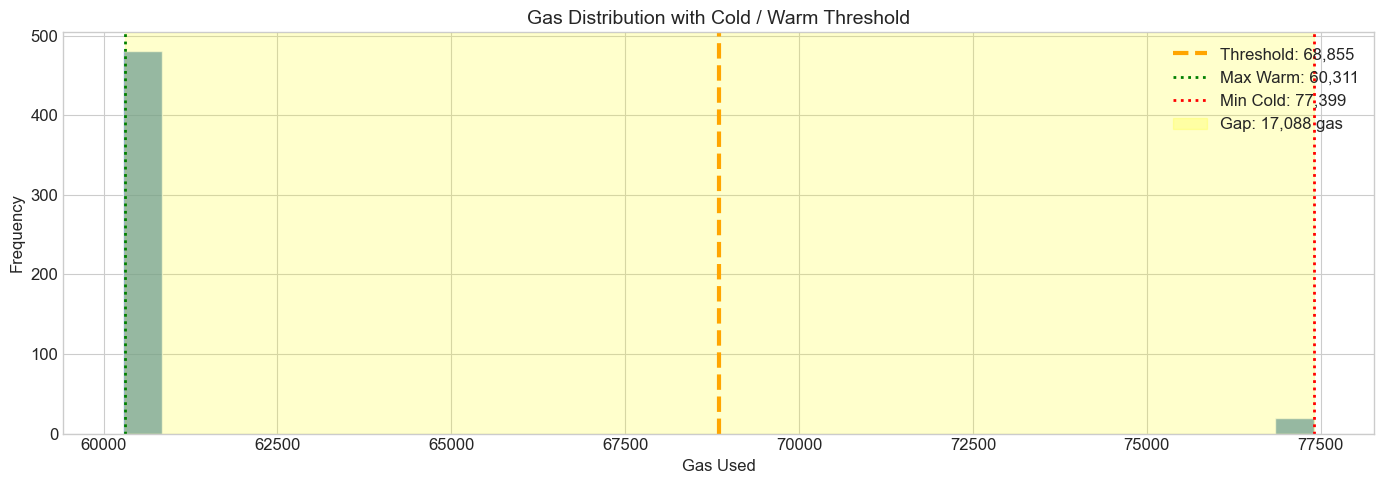

In [11]:
plt.figure(figsize=(14, 5))

df["Gas Used"].hist(
    bins=30,
    color="steelblue",
    edgecolor="white",
    alpha=0.7
)

plt.axvline(
    threshold,
    color="orange",
    linestyle="--",
    linewidth=3,
    label=f"Threshold: {threshold:,}"
)
plt.axvline(
    max_warm,
    color="green",
    linestyle=":",
    linewidth=2,
    label=f"Max Warm: {max_warm:,}"
)
plt.axvline(
    min_cold,
    color="red",
    linestyle=":",
    linewidth=2,
    label=f"Min Cold: {min_cold:,}"
)

plt.axvspan(
    max_warm,
    min_cold,
    alpha=0.2,
    color="yellow",
    label=f"Gap: {min_cold - max_warm:,} gas"
)

plt.xlabel("Gas Used")
plt.ylabel("Frequency")
plt.title("Gas Distribution with Cold / Warm Threshold")
plt.legend(loc="upper right")

plt.tight_layout()
plt.show()

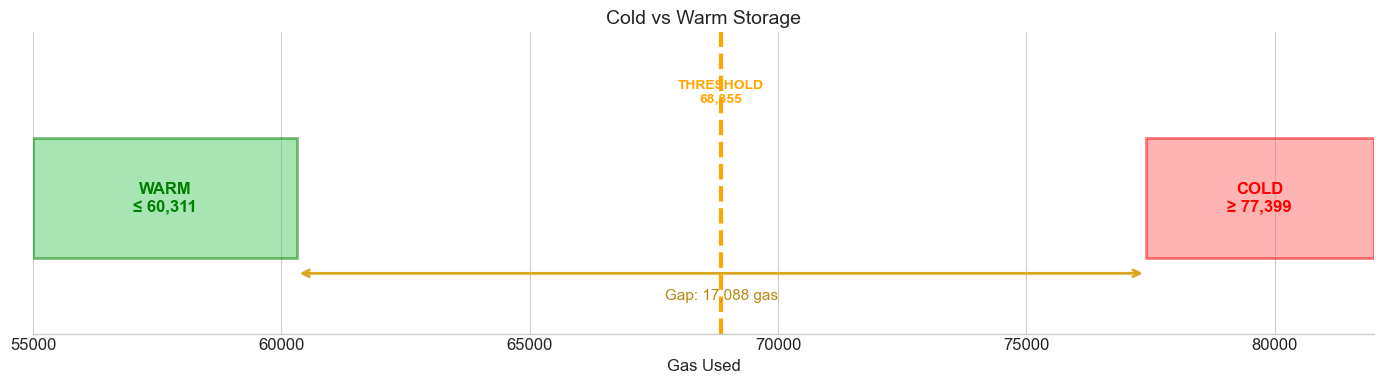

In [12]:
plt.figure(figsize=(14, 4))
ax = plt.gca()

ax.set_xlim(55000, 82000)
ax.set_ylim(0, 2)

warm_box = Rectangle(
    (55000, 0.5),
    max_warm - 55000,
    0.8,
    facecolor="#51cf66",
    alpha=0.5,
    edgecolor="green",
    linewidth=2
)

cold_box = Rectangle(
    (min_cold, 0.5),
    82000 - min_cold,
    0.8,
    facecolor="#ff6b6b",
    alpha=0.5,
    edgecolor="red",
    linewidth=2
)

ax.add_patch(warm_box)
ax.add_patch(cold_box)

ax.text(
    (55000 + max_warm) / 2,
    0.9,
    f"WARM\n≤ {max_warm:,}",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="green"
)

ax.text(
    (min_cold + 82000) / 2,
    0.9,
    f"COLD\n≥ {min_cold:,}",
    ha="center",
    va="center",
    fontsize=12,
    fontweight="bold",
    color="red"
)

ax.axvline(
    threshold,
    color="orange",
    linestyle="--",
    linewidth=3
)

ax.text(
    threshold,
    1.6,
    f"THRESHOLD\n{threshold:,}",
    ha="center",
    va="center",
    fontsize=10,
    color="orange",
    fontweight="bold"
)

ax.annotate(
    "",
    xy=(min_cold, 0.4),
    xytext=(max_warm, 0.4),
    arrowprops=dict(arrowstyle="<->", color="goldenrod", lw=2)
)

ax.text(
    (max_warm + min_cold) / 2,
    0.25,
    f"Gap: {min_cold - max_warm:,} gas",
    ha="center",
    va="center",
    fontsize=11,
    color="darkgoldenrod"
)

ax.set_title("Cold vs Warm Storage")
ax.set_xlabel("Gas Used")
ax.set_yticks([])

for spine in ["left", "right", "top"]:
    ax.spines[spine].set_visible(False)

plt.tight_layout()
plt.show()

In [13]:
df['Storage Type'] = df['Gas Used'].apply(
    lambda x: 'Cold' if x >= threshold else 'Warm'
)

cold_count = (df['Storage Type'] == 'Cold').sum()
warm_count = (df['Storage Type'] == 'Warm').sum()

print(f"\n🔴 Cold Storage Access: {cold_count} ({cold_count/len(df)*100:.1f}%)")
print(f"🔵 Warm Storage Access: {warm_count} ({warm_count/len(df)*100:.1f}%)")


🔴 Cold Storage Access: 20 (4.0%)
🔵 Warm Storage Access: 480 (96.0%)


In [14]:
avg_cold_gas = df[df['Storage Type'] == 'Cold']['Gas Used'].mean()
avg_warm_gas = df[df['Storage Type'] == 'Warm']['Gas Used'].mean()

print(f"Avg Cold Storage: {avg_cold_gas:,.0f} gas")
print(f"Avg Warm Storage: {avg_warm_gas:,.0f} gas")

Avg Cold Storage: 77,409 gas
Avg Warm Storage: 60,309 gas


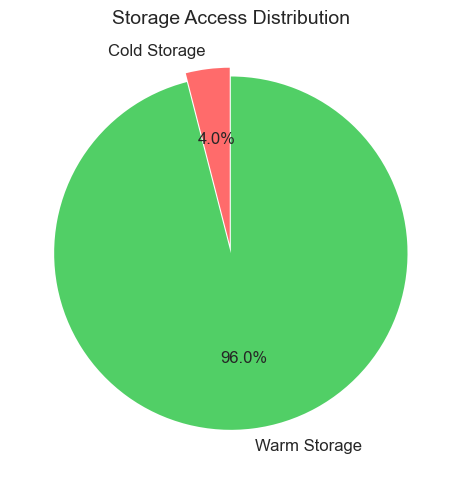

In [15]:
plt.figure(figsize=(6, 5))

colors = ['#ff6b6b', '#51cf66']
explode = (0.05, 0)

plt.pie(
    [cold_count, warm_count],
    labels=['Cold Storage', 'Warm Storage'],
    autopct='%1.1f%%',
    colors=colors,
    explode=explode,
    startangle=90
)

plt.title('Storage Access Distribution')
plt.tight_layout()
plt.show()

In [16]:
candidate_stats = df.groupby('Candidate Name').agg({
    'Gas Used': ['count', 'mean', 'min', 'max'],
    'Storage Type': lambda x: (x == 'Cold').sum()
}).round(0)

candidate_stats.columns = ['Total Votes', 'Avg Gas', 'Min Gas', 'Max Gas', 'Cold Access Count']
candidate_stats['Warm Access Count'] = candidate_stats['Total Votes'] - candidate_stats['Cold Access Count']
candidate_stats['Cold %'] = (candidate_stats['Cold Access Count'] / candidate_stats['Total Votes'] * 100).round(1)
candidate_stats['Warm %'] = (candidate_stats['Warm Access Count'] / candidate_stats['Total Votes'] * 100).round(1)
candidate_stats = candidate_stats.sort_values('Total Votes', ascending=False)
candidate_stats

,Total Votes,Avg Gas,Min Gas,Max Gas,Cold Access Count,Warm Access Count,Cold %,Warm %
Candidate Name,,,,,,,,
Ivan Petrov,31,60861.0,60299,77399,1,30,3.2,96.8
Rachel Green,31,60861.0,60275,77411,1,30,3.2,96.8
Quinn Hughes,31,60862.0,60299,77411,1,30,3.2,96.8
Nancy Drew,29,60899.0,60299,77411,1,28,3.4,96.6
Tina Turner,28,60921.0,60299,77411,1,27,3.6,96.4
Bob Smith,28,60921.0,60299,77411,1,27,3.6,96.4
George Washington,28,60921.0,60299,77399,1,27,3.6,96.4
Alice Johnson,27,60931.0,60275,77399,1,26,3.7,96.3
Michael Jordan,26,60967.0,60299,77411,1,25,3.8,96.2


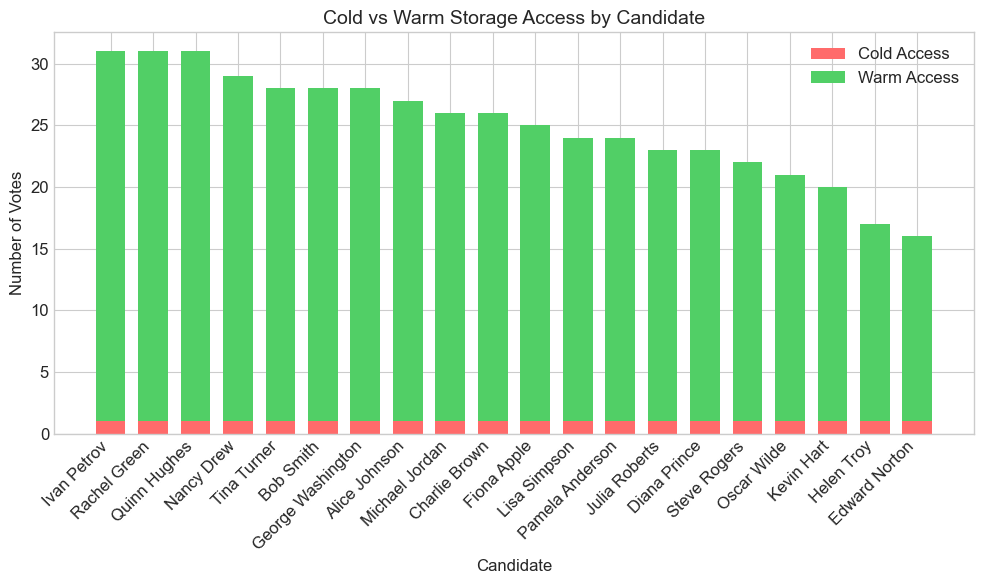

In [17]:
plt.figure(figsize=(10, 6))
ax = plt.gca()

candidates = candidate_stats.index.tolist()
cold_counts = candidate_stats["Cold Access Count"].values
warm_counts = candidate_stats["Warm Access Count"].values

x = np.arange(len(candidates))
width = 0.7

ax.bar(
    x,
    cold_counts,
    width,
    label="Cold Access",
    color="#ff6b6b"
)
ax.bar(
    x,
    warm_counts,
    width,
    bottom=cold_counts,
    label="Warm Access",
    color="#51cf66"
)

ax.set_ylabel("Number of Votes")
ax.set_xlabel("Candidate")
ax.set_title("Cold vs Warm Storage Access by Candidate")
ax.set_xticks(x)
ax.set_xticklabels(candidates, rotation=45, ha="right")
ax.legend()

plt.tight_layout()
plt.show()

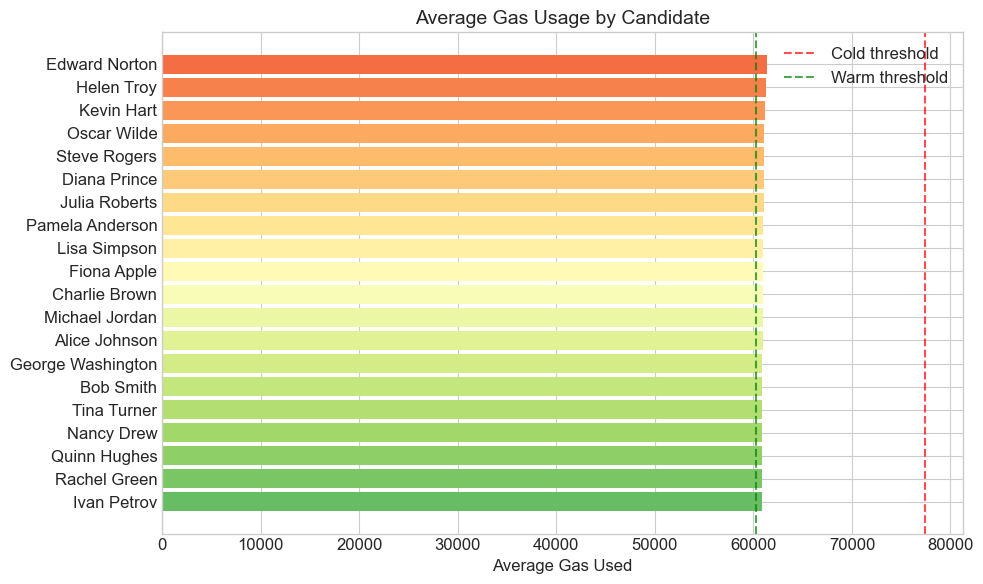

In [18]:
plt.figure(figsize=(10, 6))
ax = plt.gca()

candidates = candidate_stats.index.tolist()
avg_gas = candidate_stats["Avg Gas"].values

colors = plt.cm.RdYlGn_r(np.linspace(0.2, 0.8, len(candidates)))

ax.barh(candidates, avg_gas, color=colors)

ax.set_xlabel("Average Gas Used")
ax.set_title("Average Gas Usage by Candidate")

ax.axvline(
    avg_cold_gas,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Cold threshold"
)
ax.axvline(
    avg_warm_gas,
    color="green",
    linestyle="--",
    alpha=0.7,
    label="Warm threshold"
)

ax.legend()

plt.tight_layout()
plt.show()

In [19]:
block_stats = df.groupby('Block Number').agg({
    'Gas Used': ['mean', 'count'],
    'Storage Type': lambda x: (x == 'Cold').sum()
}).reset_index()

block_stats.columns = ['Block Number', 'Avg Gas', 'Votes', 'Cold Count']
block_stats['Warm Count'] = block_stats['Votes'] - block_stats['Cold Count']
cold_blocks = block_stats[block_stats['Cold Count'] > 0]
print(f"\n🔴 Blocks with cold access: {len(cold_blocks)}")
print(f"🔵 Blocks with only warm access: {len(block_stats) - len(cold_blocks)}")


🔴 Blocks with cold access: 20
🔵 Blocks with only warm access: 480


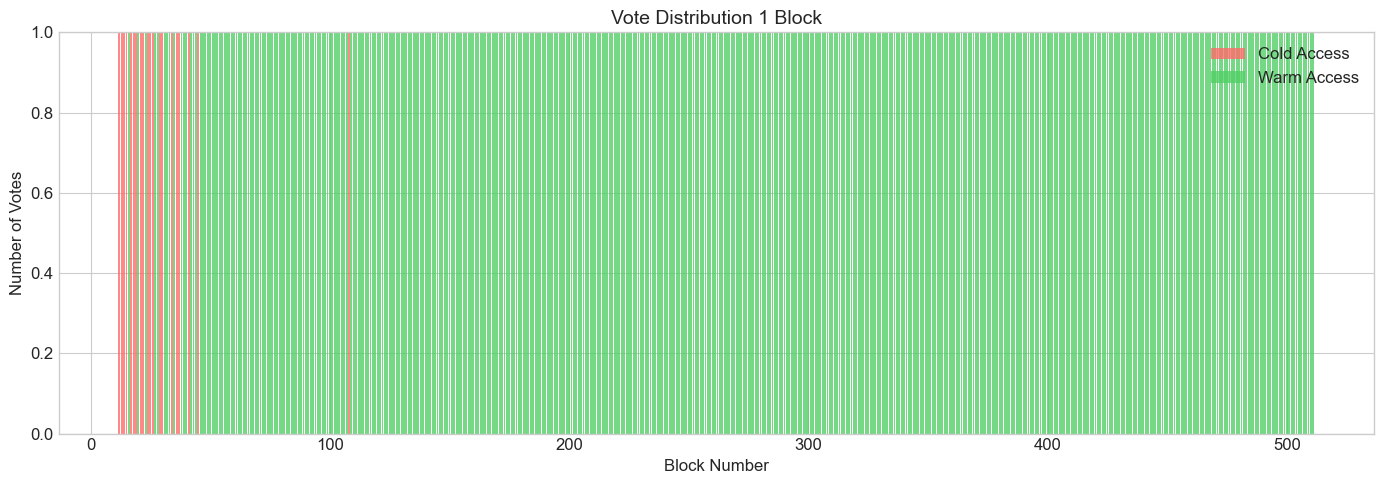

In [20]:
plt.figure(figsize=(14, 5))
ax = plt.gca()

ax.bar(
    block_stats["Block Number"],
    block_stats["Cold Count"],
    label="Cold Access",
    color="#ff6b6b",
    alpha=0.8
)

ax.bar(
    block_stats["Block Number"],
    block_stats["Warm Count"],
    bottom=block_stats["Cold Count"],
    label="Warm Access",
    color="#51cf66",
    alpha=0.8
)

ax.set_xlabel("Block Number")
ax.set_ylabel("Number of Votes")
ax.set_title("Vote Distribution 1 Block")
ax.legend()

plt.tight_layout()
plt.show()

1. GAS DISTRIBUTION
 Lower Gas, Higher Gas tier sep by THRESHOLD

2. COLD vs WARM STORAGE ACCESS
Cold: First-time access to a storage slot <=> EVM cache miss
Warm: Subsequent access to cached slot <=> EVM cache hit
Each candidate all hit cold access 1 time(first vote)

3. EXECUTION PATH DIFFERENCE
 3.1 Different voters vote for different candidates
 3.2 Each candidate's voteCount is a different storage slot
   => First access to any slot = cold, subsequent = warm
2. COLD vs WARM STORAGE ACCESS: TECHNICAL EXPLANATION

4. Compare

 4.1 Cold storage: 
1. Full Merkle Patricia Trie traversal to locate the storage slot
2. ryptographic proof verification
3. Database disk I/O to load state from persistent storage
4. Account state loading (nonce, balance, code hash)
 4.2 Warm storage

1. O(1) memory lookup (no database access)
2. Instant value retrieval from cache
3. Minimal computational overhead

 If cold access were cheap, attackers could:
  - Spam unique storage slot accesses
  - Overload the database with disk reads
  - Potentially crash network nodes

# ref

https://github.com/ethereum/EIPs/blob/master/EIPS/eip-2929.md
=== cold vs warm storage & code access gas rules

https://coinsbench.com/advanced-gas-optimizations-tips-for-solidity-85c47f413dc5
=== opcode-level gas optimization techniques

https://learnevm.com/chapters/intro/demystifying-evm-opcodes
=== explanation of EVM opcodes and execution model

https://rareskills.io/post/eip-2930-optional-access-list-ethereum
=== DoS/DDOS prevention

https://ethresear.ch/t/block-level-warming/21452
=== block / transaction level storage warming discussion

https://www.alchemy.com/docs/patricia-merkle-tries
=== Merkle Patricia Trie

